In [3]:
import sys
print(sys.executable)

C:\Users\gupta\anaconda3\envs\project_new\python.exe


In [4]:

import torchvision.transforms as transforms
import os
from PIL import Image,ImageOps,ImageFilter
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch.nn as nn
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import numpy as np
import cv2

ModuleNotFoundError: No module named 'cv2'

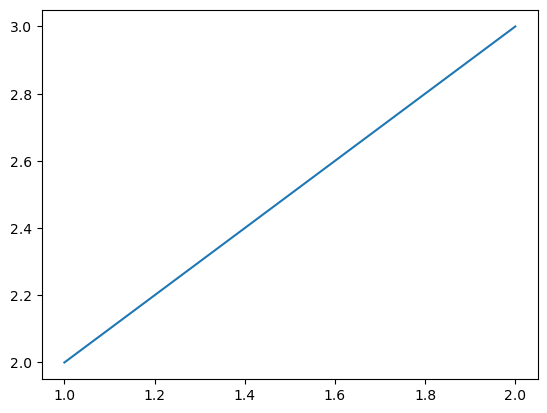

In [8]:
import matplotlib.pyplot as plt
plt.close("all")  # Close all open figures
plt.clf()         # Clear the current figure (if any)
plt.cla()       
plt.plot([1,2],[2,3])

# DATA

In [17]:
# class SiameseCNN(nn.Module):
#     def __init__(self):
#         super(SiameseCNN, self).__init__()
#         self.cnn =nn.Sequential(
#         nn.Conv2d(1, 32, 3, padding=1),
#         nn.BatchNorm2d(32),
#         nn.ReLU(),
#         nn.MaxPool2d(2),
    
#         nn.Conv2d(32, 64, 3, padding=1),
#         nn.BatchNorm2d(64),
#         nn.ReLU(),
#         nn.MaxPool2d(2),
    
#         nn.Conv2d(64, 128, 3, padding=1),
#         nn.BatchNorm2d(128),
#         nn.ReLU(),
#         nn.MaxPool2d(2),
    
#         nn.Flatten(),
#         nn.Linear(128 * 32 * 32, 256),
#         nn.ReLU(),
#         nn.Dropout(0.5),
#         nn.Linear(256, 64)
# )

#     def forward(self, x1, x2):
#         embedding1 = self.cnn(x1)
#         embedding2 = self.cnn(x2)
#         return embedding1, embedding2
class SiameseCNN(nn.Module):
    def __init__(self):
        super(SiameseCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, 5, padding=2),    nn.BatchNorm2d(64),   nn.PReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 5, padding=2),  nn.BatchNorm2d(128),  nn.PReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256),  nn.PReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256),  nn.PReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256),  nn.PReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1))   # → (B, 256, 1, 1)
        )

        # === Classifier head (after GAP) ===
        self.classifier = nn.Sequential(
            nn.Linear(256, 1024),
            nn.PReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 512)
        )

    def forward_one(self, x):
        x = self.features(x)           # → (B, 256, 1, 1)
        x = torch.flatten(x, 1)        # → (B, 256)   ← THIS WAS MISSING!
        x = self.classifier(x)         # → (B, 512)
        x = F.normalize(x, p=2, dim=1)  # ← L2 NORM — ABSOLUTELY CRITICAL!
        return x

    # Siamese forward (two images)
    def forward(self, x1, x2):
        emb1 = self.forward_one(x1)
        emb2 = self.forward_one(x2)
        return emb1, emb2


In [18]:
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, emb1, emb2, label):
        cosine_sim = nn.functional.cosine_similarity(emb1, emb2)
        loss = label * (1 - cosine_sim) + (1 - label) * torch.clamp(cosine_sim - self.margin, min=0)
        return loss.mean()
    
model = SiameseCNN()


In [19]:
# Load the model
# PATH="./saved_models/LENET/siamese_margin0.8size256_lr0.005.pt"
PATH = "./second_saved_models/savedmodels/dropoutCNN/siamese_margin0.8_size64_dropout4_lr0.0001.pt"

model = SiameseCNN().to(device)
try:
    model.load_state_dict(torch.load(PATH, map_location=device))
except RuntimeError as e:
    print(f"Error loading model: {e}")


Error loading model: Error(s) in loading state_dict for SiameseCNN:
	Missing key(s) in state_dict: "features.0.weight", "features.0.bias", "features.1.weight", "features.1.bias", "features.1.running_mean", "features.1.running_var", "features.2.weight", "features.4.weight", "features.4.bias", "features.5.weight", "features.5.bias", "features.5.running_mean", "features.5.running_var", "features.6.weight", "features.8.weight", "features.8.bias", "features.9.weight", "features.9.bias", "features.9.running_mean", "features.9.running_var", "features.10.weight", "features.11.weight", "features.11.bias", "features.12.weight", "features.12.bias", "features.12.running_mean", "features.12.running_var", "features.13.weight", "features.14.weight", "features.14.bias", "features.15.weight", "features.15.bias", "features.15.running_mean", "features.15.running_var", "features.16.weight", "classifier.0.weight", "classifier.0.bias", "classifier.1.weight", "classifier.3.weight", "classifier.3.bias". 
	Une

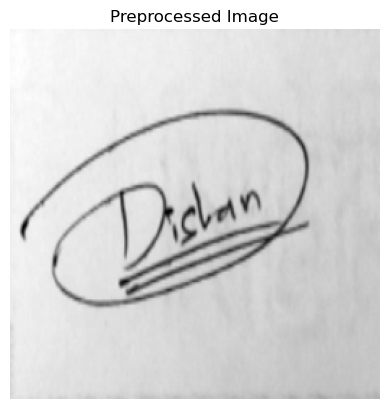

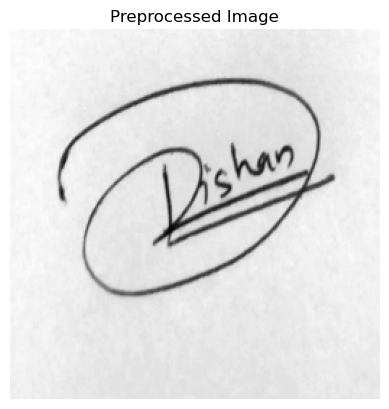

tensor([0.6285], device='cuda:0', grad_fn=<SumBackward1>)
Fake


In [9]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),  # Resize to match FashionMNIST if needed
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Standard normalization
])
ref_img_path="./real_test/ref_02.png"
gen_img_path="./real_test/gen_02.png"
fake_img_path="real_test/fake_02.png"

ref_img=transform(Image.open(ref_img_path).convert("L"))
gen_img=transform(Image.open(gen_img_path).convert("L"))
fake_img=transform(Image.open(fake_img_path).convert("L"))

img1,img2 = ref_img, gen_img
plt.imshow(img1.squeeze(0), cmap="gray")

plt.axis("off")
plt.title("Preprocessed Image")
plt.show()

plt.imshow(img2.squeeze(0), cmap="gray")
plt.axis("off")
plt.title("Preprocessed Image")
plt.show()

img1,img2=img1.unsqueeze(0).to(device),img2.unsqueeze(0).to(device)
emb1, emb2 = model(img1, img2)
emb1 = F.normalize(emb1, p=2, dim=1)
emb2 = F.normalize(emb2, p=2, dim=1)
cosine_sim = F.cosine_similarity(emb1, emb2)
print(cosine_sim)
if cosine_sim >0.8:
    print("Genuine")
else:
    print("Fake")



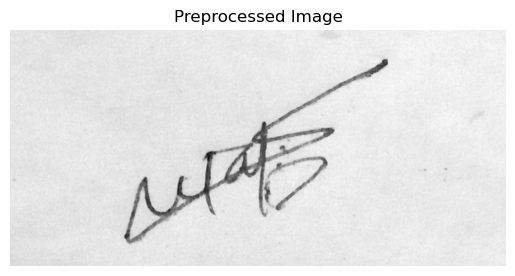

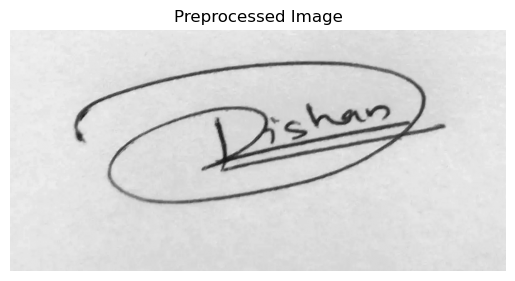

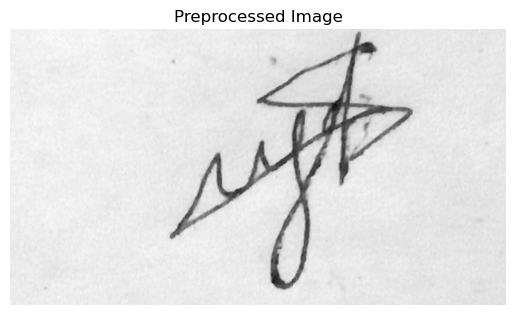

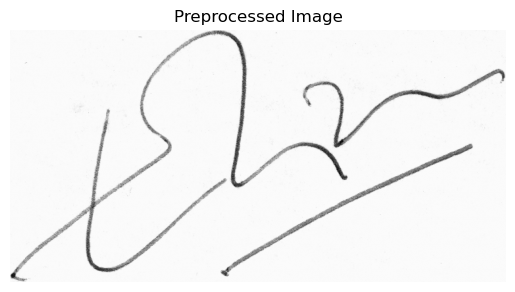

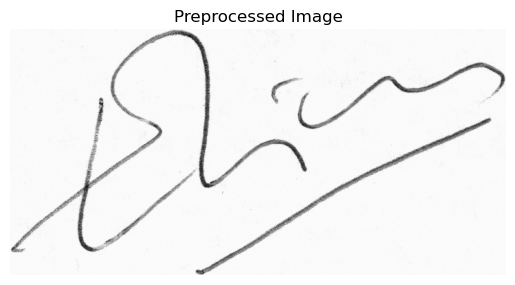

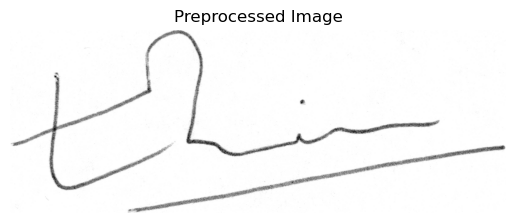

In [10]:
final_imgs=[]
# Load the first image (to preprocess)
image_paths = ("./real_test/ref_04.jpg","./real_test/gen_02.png","./real_test/fake_04.jpg  ","./real_test/ref_01.PNG","./real_test/real_01.PNG","./real_test/fake_01.png")
for image_path in image_paths:
    final_img = Image.open(image_path).convert("L")  # Convert to grayscale
    
    # # # Invert image: signature should be dark on light background
    # # inverted_img = ImageOps.invert(img)
    
    # # # Enhance contrast and binarie (thresholding)
    # # threshold = 150
    
    
    # # binary_img = inverted_img.point(lambda x: 255 if x > threshold else 0, mode='1')
    
    # # Convert binary image back to white background and black ink
    # final_img=(ImageOps.invert(binary_img.convert("L")))
    # final_imgs.append(final_img)
    # Display result
    plt.imshow(final_img, cmap="gray")
    plt.axis("off")
    plt.title("Preprocessed Image")
    plt.show()


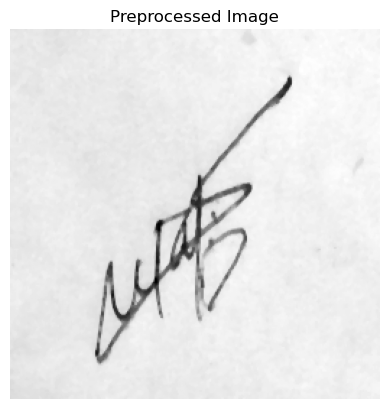

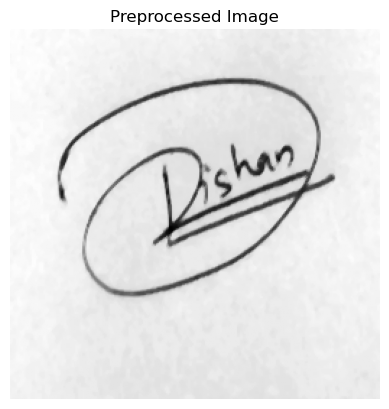

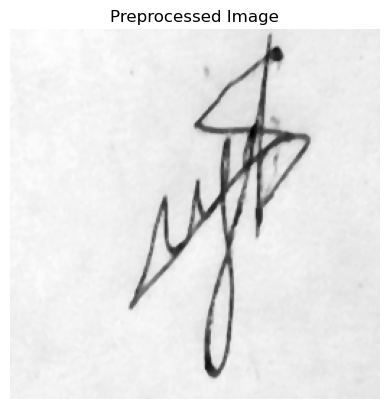

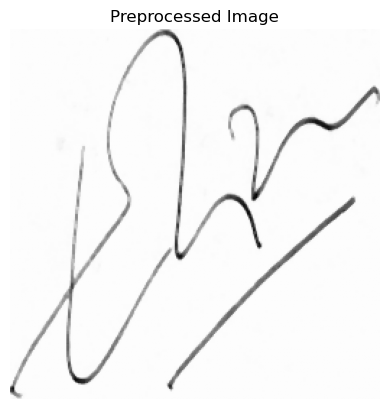

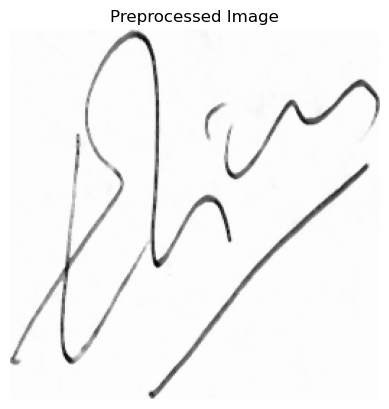

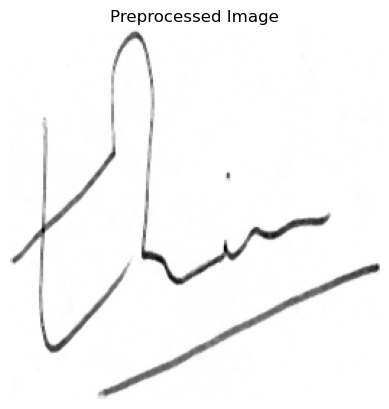

In [17]:
final_imgs=[]


# # Load the image
# image_path = 'signature.jpg'  # Replace with your image path
# img = cv2.imread(image_path)
# print("Image loaded successfully, shape:", img.shape)

# # Convert to grayscale
# gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# # Approximate autocontrast using CLAHE (Contrast Limited Adaptive Histogram Equalization)
# clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
# enhanced = clahe.apply(gray)

# # Remove noise using Gaussian blur
# blurred = cv2.GaussianBlur(enhanced, (5, 5), 0)  # 5x5 kernel, adjust sigma if needed

# # Apply binary thresholding
# _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
# # THRESH_OTSU automatically finds the optimal threshold

# # Resize to a standard size (e.g., 256x256)
# resized = cv2.resize(thresh, (256, 256), interpolation=cv2.INTER_AREA)

# # Normalize to [0, 1] for ML training
# normalized = resized / 255.0

# # Reshape for model input (e.g., add batch and channel dimensions)
# preprocessed_data = normalized.reshape(1, 256, 256, 1)  # Adjust shape based on your model

# # Optional: Save preprocessed image for inspection
# cv2.imwrite('preprocessed_signature.jpg', (normalized * 255).astype(np.uint8))

# print("Preprocessing complete. Shape:", preprocessed_data.shape)



# Load the first image (to preprocess)
image_paths = ("./real_test/ref_04.jpg","./real_test/gen_02.png","./real_test/fake_04.jpg  ","./real_test/ref_01.PNG","./real_test/real_01.PNG","./real_test/fake_01.png")
for image_path in image_paths:
    img = Image.open(image_path).convert('L')  # Convert to grayscale
    img = ImageOps.autocontrast(img)
    
    # Resize image to a standard size (e.g., 224x224)
    img = img.resize((256, 256), Image.Resampling.LANCZOS)
    img = img.filter(ImageFilter.MedianFilter(size=3))  # Size 3x3 kernel, adjust as needed
    final_imgs.append(img)
    # preprocessed_img_pil.save('preprocessed_signature.jpg')
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title("Preprocessed Image")
    plt.show()
    
    # print("Preprocessing complete. Image saved as 'preprocessed_signature.jpg'.")

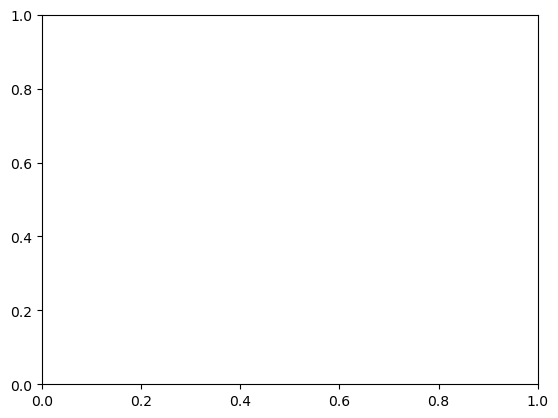

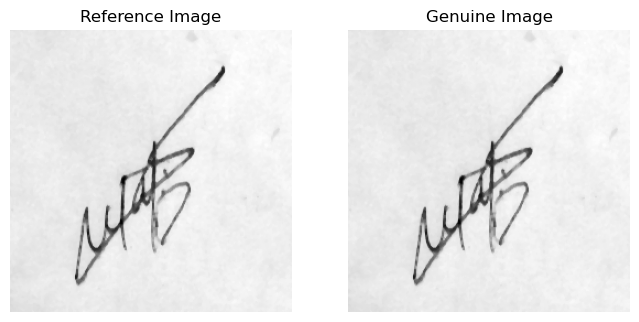

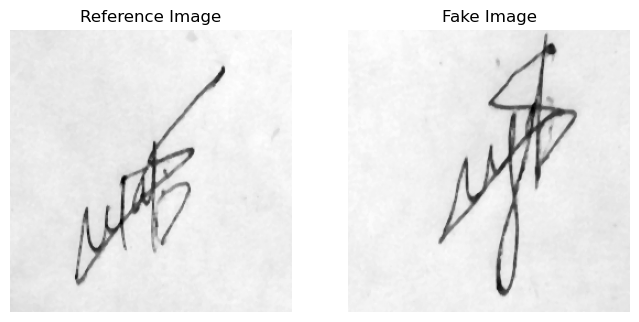

Cosine Similarity (Reference vs Genuine): 1.0000
Prediction: Genuine
Cosine Similarity (Reference vs Fake): 0.9402
Prediction: Fake


In [18]:
# Set deterministic behavior
torch.manual_seed(42)  # Set random seed for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Clear Matplotlib cache
plt.close("all")
plt.clf()
plt.cla()

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define transform
transform = transforms.Compose([
    transforms.Resize((256, 256),antialias=True),  # Resize to 64x64
    transforms.ToTensor(),        # Convert to tensor
    transforms.Normalize((0.5,), (0.5,))  # Normalize
])

# Load images
ref_img = transform(final_imgs[0])
gen_img = transform(final_imgs[0])
fake_img = transform(final_imgs[2])

# Visualize preprocessed images
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(ref_img.squeeze(0), cmap="gray")
plt.axis("off")
plt.title("Reference Image")
plt.subplot(1, 2, 2)
plt.imshow(gen_img.squeeze(0), cmap="gray")
plt.axis("off")
plt.title("Genuine Image")
plt.savefig("preprocessed_ref_gen.png")
plt.show()
plt.close("all")

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(ref_img.squeeze(0), cmap="gray")
plt.axis("off")
plt.title("Reference Image")
plt.subplot(1, 2, 2)
plt.imshow(fake_img.squeeze(0), cmap="gray")
plt.axis("off")
plt.title("Fake Image")
plt.savefig("preprocessed_ref_fake.png")
plt.show()
plt.close("all")

# Load model (replace with your SiameseCNN definition)
model = SiameseCNN().to(device)  # Ensure SiameseCNN is defined
try:
    model.load_state_dict(torch.load("./saved_models/LENET/siamese_margin0.8size256_lr0.01.pt", map_location=device))
except FileNotFoundError as e:
    print(f"Error: Model weights not found - {e}")
    exit()
model.eval()

# Clear GPU cache
torch.cuda.empty_cache()

# Test reference vs genuine
img1, img2 = ref_img.unsqueeze(0).to(device), gen_img.unsqueeze(0).to(device)
with torch.no_grad():
    emb1, emb2 = model(img1, img2)
    emb1 = F.normalize(emb1, p=2, dim=1)
    emb2 = F.normalize(emb2, p=2, dim=1)
    cosine_sim = F.cosine_similarity(emb1, emb2).item()
    print(f"Cosine Similarity (Reference vs Genuine): {cosine_sim:.4f}")
    print("Prediction: Genuine" if cosine_sim > 0.8 else "Prediction: Fake")

# Test reference vs fake
img1, img2 = ref_img.unsqueeze(0).to(device), fake_img.unsqueeze(0).to(device)
with torch.no_grad():
    emb1, emb2 = model(img1, img2)
    emb1 = F.normalize(emb1, p=2, dim=1)
    emb2 = F.normalize(emb2, p=2, dim=1)
    cosine_sim = F.cosine_similarity(emb1, emb2).item()
    print(f"Cosine Similarity (Reference vs Fake): {cosine_sim:.4f}")
    print("Prediction: Genuine" if cosine_sim > 0.97 else "Prediction: Fake")